# 07. Methane plumes: Sentinel-2 L1C around a confirmed leak

Methane absorbs short-wave infrared light, most strongly inside Sentinel-2's band B12 and only weakly in B11. A large leak therefore darkens B12 relative to B11, and comparing a scene with the leak against one without it reveals the plume. This is the data side of Varon et al. 2024 (*Nature Communications*, [10.1038/s41467-024-47754-y](https://doi.org/10.1038/s41467-024-47754-y)).

This notebook, with real data:

1. finds a confirmed leak in [Carbon Mapper](https://carbonmapper.org)'s live plume catalogue;
2. selects a Sentinel-2 L1C *detection* scene as close as possible to the confirmed date and a *reference* scene weeks earlier with `select_temporal_pair`;
3. reads both top-of-atmosphere scenes with `read_s2_l1c`;
4. tiles the scene into 2.5 x 2.5 km chips with `AnalysisGrid.chips`, the patch size the paper uses, and cuts a window centred on the leak;
5. retrieves the methane signal with the multi-band multi-pass method (MBMP, Varon et al. 2021) and saves the sample.

**Detection limit:** Sentinel-2 sees methane plumes from roughly 1 to 5 t/h upwards, depending on how bright and uniform the ground is. Most leaks in the catalogue are smaller (hyperspectral instruments such as Tanager detect a few hundred kg/h), so we search where the very large emitters are: the oil and gas fields of western Turkmenistan.

**Why L1C and not L2A:** L2A's atmospheric correction assumes a methane-free atmosphere and partly removes the very absorption we look for.

**Scope:** the paper's synthetic plume generator and its deep-learning detector are not part of this library; this notebook prepares the real inputs such a model would see.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from dotenv import dotenv_values, load_dotenv

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT = ROOT / "output" / "notebooks"
WORK = OUT / "work"  # shared download/subset cache: later notebooks reuse it
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Credentials live in the repository's .env (see docs/setup.md). The
# Earthdata token is often kept only in worker/.env; fall back to it.
load_dotenv(ROOT / ".env")
if not os.getenv("EARTHDATA_BEARER_TOKEN"):
    token = dotenv_values(ROOT / "worker" / ".env").get("EARTHDATA_BEARER_TOKEN")
    if token:
        os.environ["EARTHDATA_BEARER_TOKEN"] = token

# Upstream notices (numpy/xarray/matplotlib internals, all-NaN slices of
# cloudy scenes) that say nothing about the analysis.
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False, "image.origin": "upper"})
pd.set_option("display.max_colwidth", 70)

In [2]:
import csv
import io

import citycube as cc
from citycube.http import http_session

# Reuses the downloads of earlier runs of this analysis when present.
METHANE = ROOT / "output" / "methane-detection-carbon-mapper"
METHANE.mkdir(parents=True, exist_ok=True)

## 1. A confirmed leak from Carbon Mapper

`GET /api/v1/catalog/plume-csv` returns detected plumes as CSV with no API key needed. We search western Turkmenistan from June to September 2026, keep good-quality methane detections of at least 5 t/h, and sort by emission rate.

In [3]:
CARBON_MAPPER_API = "https://api.carbonmapper.org/api/v1/catalog/plume-csv"
BBOX = (52.0, 37.0, 56.0, 40.5)  # west, south, east, north
PERIOD = ("2026-06-01T00:00:00Z", "2026-09-30T23:59:59Z")
MIN_EMISSION_KG_H = 5000

response = http_session().get(
    CARBON_MAPPER_API,
    params=[("bbox", value) for value in BBOX] + [
        ("datetime", "/".join(PERIOD)), ("plume_gas", "CH4"), ("qualities", "good"),
        ("sort", "emissions_desc"), ("limit", 20),
    ],
    timeout=60,
)
response.raise_for_status()
plumes = pd.DataFrame(csv.DictReader(io.StringIO(response.text)))
plumes = plumes[plumes.emission_auto.astype(float) >= MIN_EMISSION_KG_H].reset_index(drop=True)
plumes[["plume_id", "datetime", "place", "instrument", "emission_auto", "emission_uncertainty_auto", "plume_latitude", "plume_longitude"]].head(10)

,plume_id,datetime,place,instrument,emission_auto,emission_uncertainty_auto,plume_latitude,plume_longitude
0,tan20260604t083758c21s4001-U,2026-06-04T08:37:58+00,Esenguly,tan,38835.57320515732,5557.245736456073,37.90827390057915,53.89843223588136
1,tan20260604t083758c21s4001-AB,2026-06-04T08:37:58+00,Esenguly,tan,23880.834269965686,2775.7104604911992,37.76746858836563,53.9168725616382
2,tan20260826t084806c27s4001-K,2026-08-26T08:48:06+00,Esenguly,tan,12627.614284412755,879.4697896202667,37.767619046297796,53.91686662858214
3,tan20260611t083132c23s4001-AW,2026-06-11T08:31:32+00,Balkanabat,tan,12477.286465263345,882.8031282129459,39.362054389927096,53.79683856462617
4,tan20260611t083132c23s4001-AR,2026-06-11T08:31:32+00,Balkanabat,tan,11606.956386736863,3339.327311209015,39.36052834435,53.76563553078606
5,tan20260611t083132c23s4001-N,2026-06-11T08:31:32+00,Balkanabat,tan,10565.614949462059,3139.8009630984625,39.4675868661171,53.63932344515135
6,tan20260826t084806c27s4001-B,2026-08-26T08:48:06+00,Esenguly,tan,10382.77588680437,1704.1846650642015,37.92848573085968,53.916701641760994
7,tan20260620t083638c93s4001-B,2026-06-20T08:36:38+00,Balkanabat,tan,8130.174850578486,1735.444099230494,39.41589692501083,54.43552655209879
8,tan20260611t083132c23s4001-O,2026-06-11T08:31:32+00,Balkanabat,tan,7408.884536024611,1822.8687263097981,39.463290392685565,53.62431596059682
9,tan20260602t082638c47s4001-J,2026-06-02T08:26:38+00,Balkanabat,tan,6151.623869517334,623.6142838772739,39.109933712663775,54.51914986201868


## 2. A leak with a usable reference and detection scene

Leaks are often intermittent, so the detection scene must be as close as possible to the date the plume was confirmed: the clearest acquisition within 3 days of it. The reference is the clearest acquisition 10 to 60 days before the detection: early enough that the leak is not expected to be the same, recent enough that the ground has not changed with the season. (The paper uses 7 days before and 30 to 120 days before, a rule for assembling training data rather than for seeing one particular plume.) `select_temporal_pair` takes both windows; we keep the largest emitter that has such a pair.

In [4]:
config = cc.ClientConfig.from_env(ROOT / ".env")
catalog = cc.Sentinel2Catalog(config, product_type=cc.SENTINEL2_L1C_PRODUCT_TYPE)
pad = 0.05  # about 5 km around the plume

for _, plume in plumes.iterrows():
    plume_lat, plume_lon = float(plume.plume_latitude), float(plume.plume_longitude)
    plume_date = plume.datetime[:10]
    aoi = cc.AOI(west=plume_lon - pad, south=plume_lat - pad, east=plume_lon + pad, north=plume_lat + pad)
    window_end = pd.Timestamp(plume_date) + pd.Timedelta(days=3)
    window_start = (window_end - pd.Timedelta(days=70)).strftime("%Y-%m-%d")
    candidates = catalog.search(aoi, window_start, window_end.strftime("%Y-%m-%d"), cloud_cover_max=40, limit=50)
    try:
        # detection within [plume date - 3 d, plume date + 3 d]; reference 10 to 60 days before that window's end
        pair = cc.select_temporal_pair(candidates, window_end.strftime("%Y-%m-%d"), detection_lookback_days=6, reference_lookback_days=(10, 60), cloud_cover_max=25.0)
    except ValueError as reason:
        print(f"skip {plume.plume_id} ({plume.place}, {plume_date}): {reason}")
        continue
    break

rate, rate_error = float(plume.emission_auto), float(plume.emission_uncertainty_auto)
print(f"\nusing {plume.plume_id}: {plume.place}, {plume.instrument}, {plume_date}, {rate:.0f} +/- {rate_error:.0f} kg/h")
print(f"reference: {pair.reference.start_datetime[:10]} cloud {pair.reference.cloud_cover}%")
print(f"detection: {pair.detection.start_datetime[:10]} cloud {pair.detection.cloud_cover}%  ({pair.gap_days:.0f} days apart)")


using tan20260604t083758c21s4001-U: Esenguly, tan, 2026-06-04, 38836 +/- 5557 kg/h
reference: 2026-05-25 cloud 0.0%
detection: 2026-06-02 cloud 0.0%  (8 days apart)


## 3. Download and read

One acquisition is split into several 110 km MGRS tiles. The detection date is read first, trying its tiles from clearest to cloudiest until one covers the AOI. For the reference date the same tile is preferred, so both scenes share exactly the same pixel grid and can be subtracted pixel by pixel. `read_s2_l1c` crops to the AOI and applies the processing-baseline radiometric offset, so values are true top-of-atmosphere reflectance.

In [5]:
import re

downloader = cc.CDSEDownloader(config, cache=cc.AssetCache(METHANE / "cache"))


def tile_of(product):
    match = re.search(r"_T(\d{2}[A-Z]{3})_", product.name)
    return match.group(1) if match else None


def read_scene(chosen, prefer_tile=None):
    day = chosen.start_datetime[:10]
    same_day = [p for p in candidates if p.start_datetime and p.start_datetime[:10] == day]
    order = sorted(same_day, key=lambda p: (tile_of(p) != prefer_tile, p.cloud_cover if p.cloud_cover is not None else 101.0))
    for product in order:
        archive = downloader.download(product, METHANE / "downloads")
        try:
            return cc.read_s2_l1c(archive, aoi=aoi), product
        except ValueError:
            continue  # this tile does not cover the AOI
    raise RuntimeError(f"no tile on {day} covers the AOI")


detection, detection_product = read_scene(pair.detection)
reference, reference_product = read_scene(pair.reference, prefer_tile=tile_of(detection_product))
assert reference.attrs["crs"] == detection.attrs["crs"] and np.array_equal(reference.x, detection.x), "the two dates are on different grids"
print("tile", tile_of(detection_product), dict(detection.sizes), "bands:", [name for name in detection.data_vars if name.startswith("B")])

tile 39SYC {'time': 1, 'y': 569, 'x': 457} bands: ['B01', 'B02', 'B03', 'B04', 'B05', 'B08', 'B8A', 'B09', 'B11', 'B12']


## 4. Chips and a window around the leak

`AnalysisGrid.chips` tiles the scene's own grid into equal 2.5 km patches, which is how a training dataset of many scenes would be cut. A fixed tiling can put the source on a chip edge, so to look at the plume we cut a 5 km window centred on the reported source instead.

In [6]:
from pyproj import Transformer

resolution = detection.attrs["resolution_m"]
bounds = (float(detection.x.min()) - resolution / 2, float(detection.y.min()) - resolution / 2,
          float(detection.x.max()) + resolution / 2, float(detection.y.max()) + resolution / 2)
scene_grid = cc.AnalysisGrid.from_bounds(bounds, crs=detection.attrs["crs"], resolution_m=resolution)
chips = scene_grid.chips(2500)
plume_x, plume_y = Transformer.from_crs("EPSG:4326", scene_grid.crs, always_xy=True).transform(plume_lon, plume_lat)
chip = next(c for c in chips if c.bounds[0] <= plume_x <= c.bounds[2] and c.bounds[1] <= plume_y <= c.bounds[3])
HALF = 2500  # metres: a 5 x 5 km window centred on the source


def clip(dataset):
    return dataset.sel(x=slice(plume_x - HALF, plume_x + HALF), y=slice(plume_y + HALF, plume_y - HALF)).isel(time=0, drop=True)


ref_chip, det_chip = clip(reference), clip(detection)
print(f"{len(chips)} chips of 2.5 km tile the scene; the source lies in {chip.grid_id}")
print(f"window around the source: {dict(det_chip.sizes)} pixels of {resolution:.0f} m")

12 chips of 2.5 km tile the scene; the source lies in EPSG:32639:20m:750240,4.1939e+06,759400,4.2053e+06:chip:2:1
window around the source: {'y': 250, 'x': 250} pixels of 20 m


## 5. Retrieving the methane signal

Methane absorbs strongly in B12 and barely in B11, so the ratio between them is what carries the signal. Surfaces also differ between the two bands, and the retrieval methods differ in how they remove that:

* **Single-band, multi-pass:** the B12 change between the dates. Anything that changed on the ground competes with the plume.
* **MBSP (multi-band single-pass):** on the detection date alone, B12 is compared with B11 scaled to it over the window, giving the fractional B12 absorption. It needs no reference, and works best over uniform ground.
* **MBMP (multi-band multi-pass, Varon et al. 2021):** the MBSP of the detection date minus that of the reference date, which also removes surface features present on both dates.

Negative values (red) mean extra B12 absorption, that is, more methane.

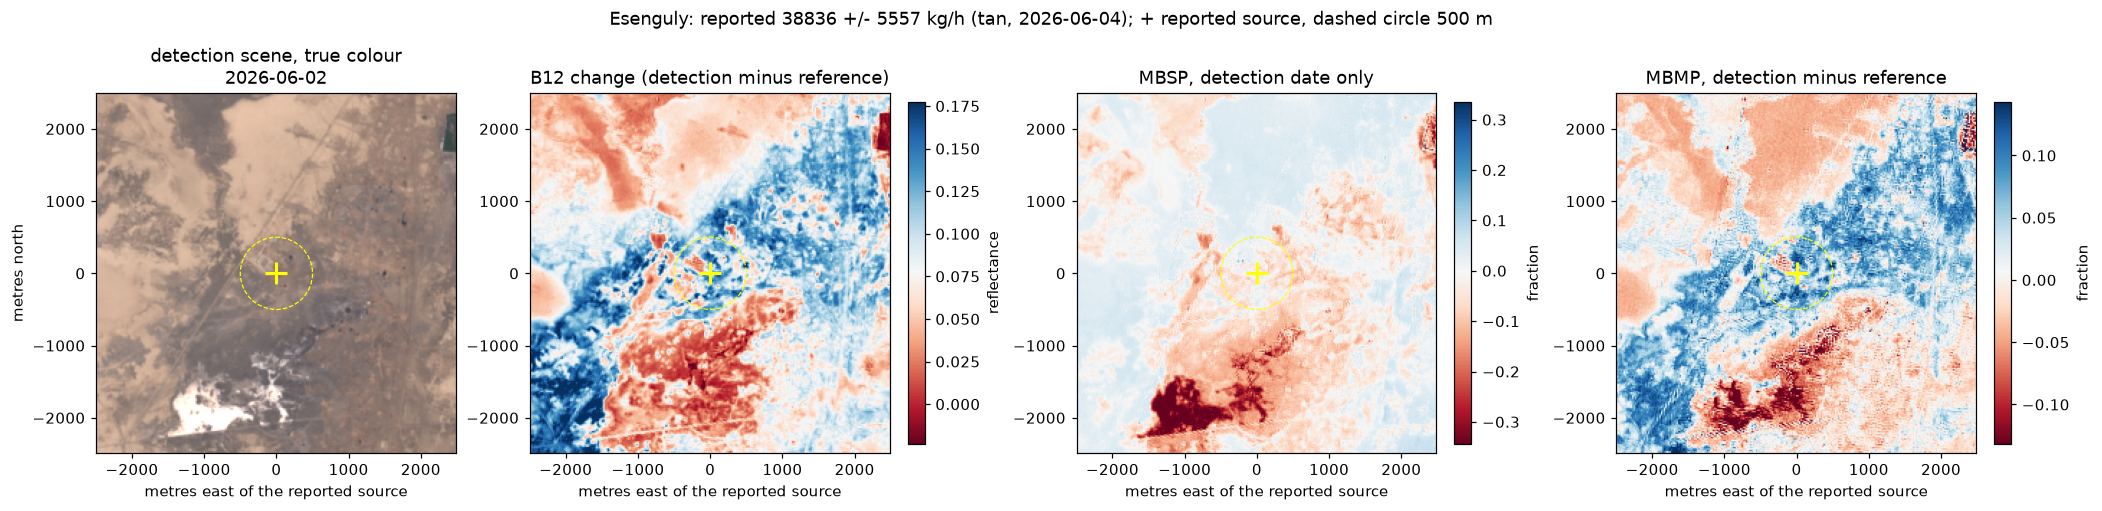

In [7]:
def fractional_b12_absorption(scene):
    """MBSP: B12 against B11 scaled to it by least squares over the window."""
    b11, b12 = scene["B11"], scene["B12"]
    scale = float((b11 * b12).sum() / (b11 * b11).sum())
    return (b12 - scale * b11) / (scale * b11)


single_band = det_chip["B12"] - ref_chip["B12"]
mbsp = fractional_b12_absorption(det_chip)
mbmp = mbsp - fractional_b12_absorption(ref_chip)


def extent(da):
    return [float(da.x.min()) - plume_x, float(da.x.max()) - plume_x, float(da.y.min()) - plume_y, float(da.y.max()) - plume_y]


def rgb(scene):
    stack = np.dstack([scene[b].values for b in ("B04", "B03", "B02")])
    return np.clip(stack / np.nanpercentile(stack, 99), 0, 1)


fig, axes = plt.subplots(1, 4, figsize=(19, 4.6), constrained_layout=True)
axes[0].imshow(rgb(det_chip), extent=extent(det_chip))
axes[0].set_title(f"detection scene, true colour\n{detection_product.start_datetime[:10]}")
for ax, data, title, label in (
    (axes[1], single_band, "B12 change (detection minus reference)", "reflectance"),
    (axes[2], mbsp, "MBSP, detection date only", "fraction"),
    (axes[3], mbmp, "MBMP, detection minus reference", "fraction"),
):
    limit = float(np.nanpercentile(np.abs(data.values - np.nanmedian(data.values)), 99))
    centre = float(np.nanmedian(data.values))
    image = ax.imshow(data.values, extent=extent(data), cmap="RdBu", vmin=centre - limit, vmax=centre + limit)
    ax.set_title(title)
    plt.colorbar(image, ax=ax, shrink=0.8, label=label)
for ax in axes:
    ax.plot(0, 0, marker="+", color="yellow", markersize=14, mew=2)
    ax.add_patch(plt.Circle((0, 0), 500, fill=False, color="yellow", lw=0.8, ls="--"))
    ax.set_xlabel("metres east of the reported source")
axes[0].set_ylabel("metres north")
fig.suptitle(f"{plume.place}: reported {rate:.0f} +/- {rate_error:.0f} kg/h ({plume.instrument}, {plume_date}); + reported source, dashed circle 500 m")
fig.savefig(FIGURES / "07_methane_chip.png", bbox_inches="tight")
plt.show()

### Is there a plume?

A plume shows up as an elongated negative feature starting at the source and drifting downwind. A simple objective check is how unusual the signal within 500 m of the source is compared with the rest of the window, in robust standard deviations (a score below about -2 is a candidate).

In [8]:
dx, dy = np.meshgrid(det_chip.x.values - plume_x, det_chip.y.values - plume_y)
near_source = np.hypot(dx, dy) <= 500


def source_score(field):
    values = field.values
    median = np.nanmedian(values)
    spread = 1.4826 * np.nanmedian(np.abs(values - median))  # robust standard deviation
    return (np.nanmean(values[near_source]) - median) / spread


pd.DataFrame({"robust z-score within 500 m": {"MBSP": source_score(mbsp), "MBMP": source_score(mbmp)}}).round(2)

,robust z-score within 500 m
MBSP,-0.34
MBMP,0.93


If neither score stands out and no plume-shaped feature is visible, the usual reasons are:

* **the leak was not active at the Sentinel-2 overpass.** Large leaks are often intermittent, and the confirmation (here by an airborne or Tanager overpass) is from a different day;
* **surface change dominates**, for example after rain, which brightens or darkens the whole window between the two dates (the single-band change panel shows this);
* **bright or dark surfaces** such as salt flats, water, fresh tarmac or cloud edges produce strong MBMP features that are not methane: check the true-colour panel first;
* **the emission is below Sentinel-2's detection limit** for this surface.

This is why the paper trains a model on many such chips rather than thresholding one: a single pair is rarely conclusive.

## 6. Save the chip

A training or validation sample is the pair of scenes over the window plus the retrieved signal and the plume's metadata. NetCDF keeps it self-describing.

In [9]:
sample = xr.Dataset({
    "reference_B11": ref_chip["B11"], "reference_B12": ref_chip["B12"],
    "detection_B11": det_chip["B11"], "detection_B12": det_chip["B12"],
    "mbsp": mbsp, "mbmp": mbmp,
}, attrs={
    "crs": chip.crs, "plume_id": plume.plume_id, "plume_latitude": plume_lat, "plume_longitude": plume_lon,
    "emission_kg_h": rate, "emission_uncertainty_kg_h": rate_error,
    "reference_product": reference_product.name, "detection_product": detection_product.name,
})
path = cc.write_netcdf(sample, OUT / "07_methane_chip.nc")
print(path, f"{path.stat().st_size / 1e3:.0f} kB")

/home/jshz/Sentinel-Orchestrator/output/notebooks/07_methane_chip.nc 1517 kB


## What is not here

* **The synthetic training generator** of the paper (Gaussian plumes with Beer-Lambert absorption injected into real background scenes).
* **The detector** (a Vision Transformer encoder with a U-Net decoder).
* **A Carbon Mapper provider class**: the catalogue is queried as plain code because nothing else in the library consumes plume detections yet.